In [1]:
import os
import json
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utils import (
    get_db_connection, apply_poster_style, MAIN_COLOR,
    FONT_SIZE_LABEL, FONT_SIZE_TICKS
)

# Constants
PERSONAL_DB = "/scratch/gpfs/GRIFFITHS/hl4291/personal.db"
EPSILON = 1e-6
LIMIT_N = 100000  # Use None for full dataset

In [2]:
# 1. Connect
# src_dir = os.path.dirname(os.path.abspath(__file__))
print(f"Connecting to {PERSONAL_DB}...")
conn = duckdb.connect(database=PERSONAL_DB, read_only=False)

# 2. SQL Pre-calculation
limit_clause = f"LIMIT {LIMIT_N}" if LIMIT_N is not None else ""
print(f"Creating SQL tables _selected_moves and stats (limit={LIMIT_N or 'FULL'})...")

conn.execute(f"""
    CREATE OR REPLACE TABLE _selected_moves AS
    SELECT 
        gid,
        move_ply,
        player_clock_time,
        opponent_clock_time, 
        ln(player_clock_time + {EPSILON}) as ln_player_clock_time, 
        ln(opponent_clock_time + {EPSILON}) as ln_opponent_clock_time, 
        ln(move_time + {EPSILON}) as ln_move_time,
        ntile(10) over (order by move_ply) as qbin_move_ply,
        ntile(10) over (order by player_clock_time) as qbin_player_clock_time,
        ntile(10) over (order by opponent_clock_time) as qbin_opponent_clock_time
    FROM (
        SELECT *
        FROM selected_moves
        {limit_clause}
    );
""")

conn.execute(f"""
    CREATE OR REPLACE TABLE _stats AS
    SELECT 
        qbin_player_clock_time as qbin,
        avg(qbin_player_clock_time) as mean_qbin,
        avg(ln_move_time) as mean_y,
        stddev(ln_move_time) as std_y,
        count(*) as n
    FROM _selected_moves
    GROUP BY qbin_player_clock_time;
""")

# 3. Get Counts from processed table
print("Getting processed dataset counts...")
n_games = conn.execute("SELECT count(distinct gid) FROM _selected_moves").fetchone()[0]
n_moves = conn.execute("SELECT count(*) FROM _selected_moves").fetchone()[0]
print(f"Total Games: {n_games:,} | Total Moves: {n_moves:,}")

Connecting to /scratch/gpfs/GRIFFITHS/hl4291/personal.db...
Creating SQL tables _selected_moves and stats (limit=100000)...
Getting processed dataset counts...
Total Games: 1,382 | Total Moves: 100,000


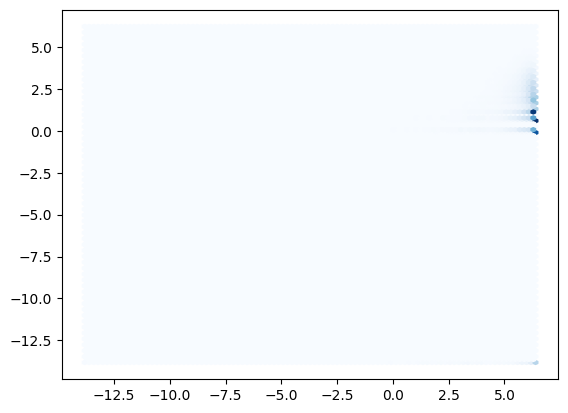

In [3]:
df = conn.execute("SELECT * FROM _selected_moves").df()

fig, ax = plt.subplots(1, 1)
ax.hexbin(df.ln_player_clock_time, df.ln_move_time, cmap = "Blues")

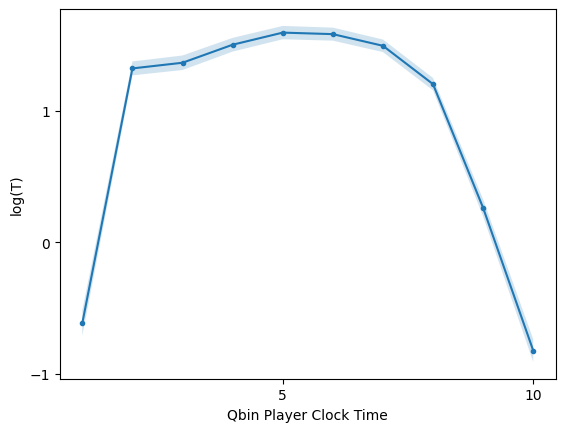

In [4]:
def plot_qbin_stats(ax, stats, xlabel, ylabel): 
    apply_poster_style()
    stats = conn.execute("SELECT * FROM _stats").df()
    stats = stats.sort_values('qbin')
    stats['sem'] = stats['std_y'] / np.sqrt(stats['n'])
    stats['ci_y'] = 1.96 * stats['sem']

    y_mean = stats['mean_y']
    y_lower = y_mean - stats['ci_y']
    y_upper = y_mean + stats['ci_y']

    ax.plot(stats['mean_qbin'], y_mean, marker='o', markersize=3, label="Mean")
    ax.fill_between(stats['mean_qbin'], y_lower, y_upper, alpha=0.2, label="95% CI")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

fig, ax = plt.subplots(1, 1)
stats = conn.execute("SELECT * FROM _stats").df()
plot_qbin_stats(ax, stats, "Qbin Player Clock Time", "log(T)")